Análisis Topológico de Datos (TDA) sobre trayectorias AIS

En este notebook se aplica homología persistente para caracterizar la
estructura geométrica de las trayectorias AIS en el espacio de
características derivadas.

A diferencia de los métodos estadísticos del pipeline anterior (AE, LOF,
reglas), el TDA captura propiedades **topológicas** de las trayectorias:
componentes conexas (H₀) y bucles o ciclos (H₁). Un valor elevado de H₁
indica que la trayectoria describe estructuras cíclicas en el espacio de
características — la firma geométrica de comportamientos erráticos o
repetitivos.

**Nota metodológica:** Se aplica TDA sobre el espacio de características
derivadas (velocidad, rumbo, giro, etc.), no sobre coordenadas geográficas
crudas. Esto es coherente con el resto del pipeline y permite comparar
directamente los resultados topológicos con el `risk_proxy` ya construido.

## Imports

In [ ]:
!pip install ripser persim -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr, spearmanr
from ripser import ripser
from persim import plot_diagrams

## Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
DATA_PATH = "/content/drive/MyDrive/TFG/results/ranking/ranking_input_v2.csv"

df = pd.read_csv(DATA_PATH)

print(df.shape)


(29141, 32)


In [ ]:
print(f"risk_proxy — min: {df['risk_proxy'].min():.4f}, "
      f"max: {df['risk_proxy'].max():.4f}, "
      f"media: {df['risk_proxy'].mean():.4f}")

risk_proxy — min: 0.0000, max: 0.9035, media: 0.1678


In [ ]:
df.head()

,MMSI,trajectory_id,segment_id,ae_score,lof_score,hybrid_score,hybrid_score_norm,rule_score_raw,rule_score_norm,potential_real_anomaly,...,course_instability,distance_km,duration,ais_gap,slow_motion,high_speed_flag,low_distance_flag,erratic_motion_flag,risk_proxy,risk_label
0,367689040,1,923622,0.000082,1.071137,0.060992,0.096090,2.5,0.304878,NaN,...,7.166667,3.942684,759.000000,2.615385,0,0,0,0,0.170827,2
1,368161380,0,1170073,1.062951,3.388275,0.263889,0.415745,1.0,0.121951,0.0,...,14.325000,0.003446,720.000000,1.000000,1,1,1,0,0.200389,2
2,366838630,1,370317,0.000492,1.021555,0.126938,0.199985,5.2,0.634146,0.0,...,90.037500,0.000000,691.000000,3.501326,1,0,1,1,0.355360,3
3,367030830,6,505747,0.000468,1.004585,0.053762,0.084699,2.2,0.268293,NaN,...,114.230769,20.507550,859.000000,1.341227,1,0,0,1,0.150376,1
4,367480130,0,730307,0.150122,298.980127,0.033823,0.053286,0.0,0.000000,NaN,...,4.025000,0.002199,1220.558226,1.016667,1,0,1,0,0.018650,0


## Construcción de trayectorias globales y subtrayectorias



El dataset opera a nivel de segmento individual. Para aplicar TDA necesitamos
agrupar segmentos en trayectorias y construir nubes de puntos donde cada
punto es un segmento representado por sus características cinemáticas.

Bajamos el umbral mínimo a 6 segmentos por trayectoria (antes era 30) para
aprovechar más datos. Usamos ventanas de 20 segmentos en lugar de 50.

In [ ]:
# Identificador único de trayectoria
df["trajectory_global"] = (
    df["MMSI"].astype(str) + "_" + df["trajectory_id"].astype(str)
)

traj_lengths = df["trajectory_global"].value_counts()

print("Distribución de longitudes de trayectoria:")
print(traj_lengths.describe().round(1))
print()

# Filtro más permisivo — mínimo 6 segmentos
valid_traj = traj_lengths[traj_lengths >= 6].index
df_tda = df[df["trajectory_global"].isin(valid_traj)].copy()

print(f"Trayectorias totales:  {traj_lengths.shape[0]:,}")
print(f"Trayectorias usadas (≥6 seg): {len(valid_traj):,}")
print(f"Segmentos en df_tda:  {df_tda.shape[0]:,}")

Distribución de longitudes de trayectoria:
count    2904.0
mean       10.0
std        14.2
min         1.0
25%         2.0
50%         5.0
75%        11.0
max       109.0
Name: count, dtype: float64

Trayectorias totales:  2,904
Trayectorias usadas (≥6 seg): 1,345
Segmentos en df_tda:  25,118


In [ ]:
# Ventana de 20 segmentos — más trayectorias procesables
WINDOW_SIZE = 20

df_tda = df_tda.sort_values(["trajectory_global", "segment_id"])

df_tda["subtraj_id"] = (
    df_tda.groupby("trajectory_global").cumcount() // WINDOW_SIZE
)
df_tda["subtraj_global"] = (
    df_tda["trajectory_global"] + "_" +
    df_tda["subtraj_id"].astype(str)
)

subtraj_sizes = df_tda.groupby("subtraj_global").size()
# Solo subtrayectorias con al menos 8 puntos
valid_subtraj = subtraj_sizes[subtraj_sizes >= 8].index
df_tda = df_tda[df_tda["subtraj_global"].isin(valid_subtraj)]

print(f"Subtrayectorias totales:  {subtraj_sizes.shape[0]:,}")
print(f"Subtrayectorias válidas (≥8):  {len(valid_subtraj):,}")

Subtrayectorias totales:  1,949
Subtrayectorias válidas (≥8):  1,429


## TDA

Usamos 6 características cinemáticas disponibles en el dataset:
- `speed_mean`: velocidad media del segmento
- `delta_course_mean`: cambio medio de rumbo  
- `turning_rate_mean`: tasa de giro media
- `course_instability`: inestabilidad del rumbo
- `distance_km`: distancia recorrida
- `ais_gap`: ratio de gap de transmisión

Cada subtrayectoria se convierte en una nube de puntos en ℝ⁶ donde cada
punto es un segmento. La filtración de Vietoris-Rips sobre esta nube
captura la estructura topológica del comportamiento de navegación.

In [ ]:
FEATURES = [
    "speed_mean", "delta_course_mean", "turning_rate_mean",
    "course_instability", "distance_km", "ais_gap"
]

def compute_tda_features(points):
    """
    Calcula características de homología persistente H₀ y H₁.

    Returns: h0_sum, h1_max, h1_sum, n_loops, diagrams
    """
    result = ripser(points, maxdim=1)
    dgms = result["dgms"]

    # H0 — componentes conexas
    h0 = dgms[0]
    h0_finite = h0[h0[:, 1] < np.inf]
    h0_sum = np.sum(h0_finite[:, 1] - h0_finite[:, 0]) if len(h0_finite) > 0 else 0

    # H1 — bucles/ciclos
    h1 = dgms[1]
    h1_finite = h1[h1[:, 1] < np.inf] if len(h1) > 0 else np.array([])

    if len(h1_finite) == 0:
        return h0_sum, 0, 0, 0, dgms

    lifetimes = h1_finite[:, 1] - h1_finite[:, 0]
    return (
        h0_sum,
        float(lifetimes.max()),
        float(lifetimes.sum()),
        len(h1_finite),
        dgms
    )

print("Función TDA definida")

Función TDA definida


In [ ]:
tda_results = []
sample_diagrams = {}  # guardamos algunos diagramas para visualizar

scaler = StandardScaler()

# Ajustamos el scaler con todos los datos disponibles
all_points = df_tda[FEATURES].dropna().values
scaler.fit(all_points)

for subtraj, group in df_tda.groupby("subtraj_global"):
    group_clean = group.dropna(subset=FEATURES)
    if len(group_clean) < 8:
        continue

    points = scaler.transform(group_clean[FEATURES].values)
    h0_sum, h1_max, h1_sum, n_loops, dgms = compute_tda_features(points)

    # Guardar algunos diagramas representativos
    risk_mean = group_clean["risk_proxy"].mean()
    if risk_mean > 0.5 and "high_risk" not in sample_diagrams:
        sample_diagrams["high_risk"] = (dgms, risk_mean, subtraj)
    if risk_mean < 0.1 and "low_risk" not in sample_diagrams:
        sample_diagrams["low_risk"] = (dgms, risk_mean, subtraj)

    tda_results.append({
        "subtraj_global": subtraj,
        "tda_h0_sum":  h0_sum,
        "tda_h1_max":  h1_max,
        "tda_h1_sum":  h1_sum,
        "tda_n_loops": n_loops,
        "risk_proxy_mean": risk_mean,
        "risk_label_mode": group_clean["risk_label"].mode()[0],
        "n_points": len(group_clean)
    })

tda_df = pd.DataFrame(tda_results)
print(f"Subtrayectorias procesadas: {len(tda_df):,}")
print(f"\nEstadísticas TDA:")
print(tda_df[["tda_h1_max","tda_h1_sum","tda_n_loops","risk_proxy_mean"]].describe().round(4))

Subtrayectorias procesadas: 1,429

Estadísticas TDA:
       tda_h1_max  tda_h1_sum  tda_n_loops  risk_proxy_mean
count   1429.0000   1429.0000    1429.0000        1429.0000
mean       0.0461      0.0595       0.8244           0.1684
std        0.0838      0.1132       1.0914           0.0436
min        0.0000      0.0000       0.0000           0.0000
25%        0.0000      0.0000       0.0000           0.1480
50%        0.0000      0.0000       0.0000           0.1695
75%        0.0586      0.0739       1.0000           0.1943
max        0.6203      1.2507       6.0000           0.3225


## Visualización: Diagramas de persistencia



Un diagrama de persistencia representa cada característica topológica
como un punto (nacimiento, muerte). Los puntos lejos de la diagonal
corresponden a características **persistentes** — las más significativas.

Comparamos el diagrama de una subtrayectoria de alto riesgo vs una de
bajo riesgo para ver si existe diferencia topológica visible.

In [ ]:
# Seleccionar automáticamente una subtrayectoria de bajo y alto riesgo
low_id = tda_df.sort_values("risk_proxy_mean").iloc[0]["subtraj_global"]
high_id = tda_df.sort_values("risk_proxy_mean", ascending=False).iloc[0]["subtraj_global"]

sample_diagrams = {}

for key, subtraj_id in {
    "low_risk": low_id,
    "high_risk": high_id
}.items():

    group = df_tda[df_tda["subtraj_global"] == subtraj_id].dropna(subset=FEATURES)
    points = scaler.transform(group[FEATURES].values)

    dgms = ripser(points, maxdim=1)["dgms"]
    risk_val = group["risk_proxy"].mean()

    sample_diagrams[key] = (dgms, risk_val, subtraj_id)

print("Bajo riesgo:", sample_diagrams["low_risk"][2], sample_diagrams["low_risk"][1])
print("Alto riesgo:", sample_diagrams["high_risk"][2], sample_diagrams["high_risk"][1])

Bajo riesgo: 367540040_0_0 2.385388242683668e-06
Alto riesgo: 368130050_0_1 0.3225424092225083


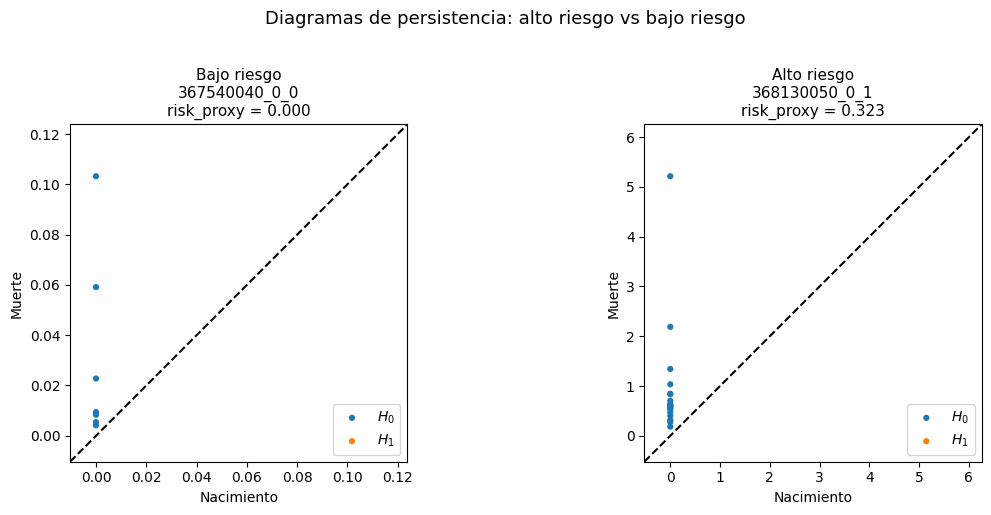

Guardado: barcode_comparison.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, key, label in zip(
    axes,
    ["low_risk", "high_risk"],
    ["Bajo riesgo", "Alto riesgo"]
):
    if key not in sample_diagrams:
        ax.text(0.5, 0.5, "No disponible", ha='center', va='center')
        ax.set_title(label)
        continue

    dgms, risk_val, subtraj_id = sample_diagrams[key]

    # Filtrar infinitos para visualización
    dgms_plot = []
    for d in dgms:
        finite = d[d[:, 1] < np.inf] if len(d) > 0 else d
        dgms_plot.append(finite)

    plot_diagrams(dgms_plot, ax=ax, show=False)
    ax.set_title(
        f"{label}\n{subtraj_id}\nrisk_proxy = {risk_val:.3f}",
        fontsize=11
    )
    ax.set_xlabel("Nacimiento")
    ax.set_ylabel("Muerte")

plt.suptitle(
    "Diagramas de persistencia: alto riesgo vs bajo riesgo",
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.savefig("barcode_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Guardado: barcode_comparison.png")

/tmp/ipykernel_1275/10927478.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=labels, patch_artist=True)


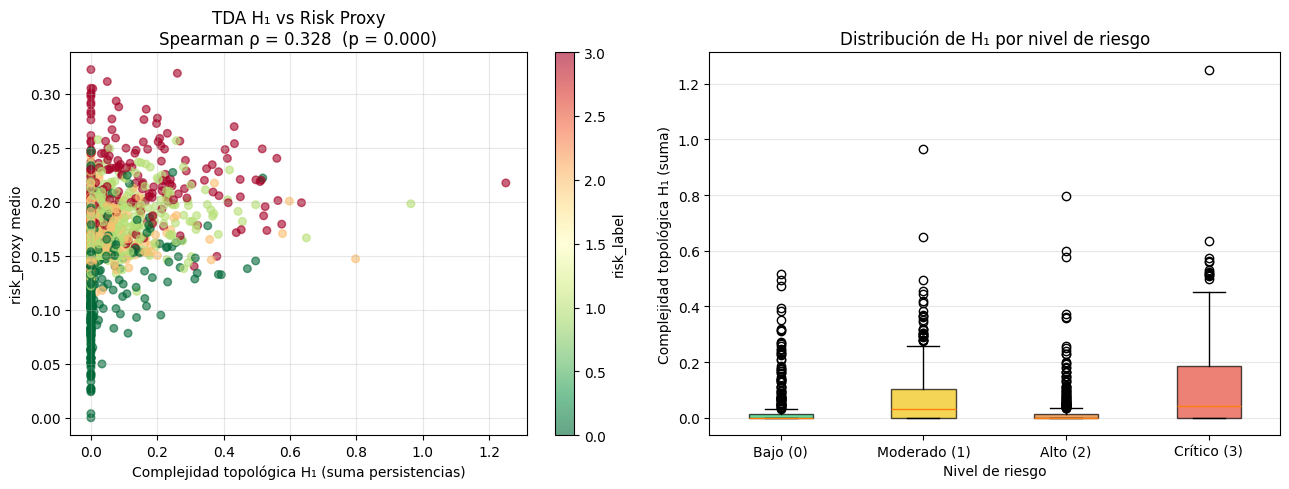

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# — Scatter H1_sum vs risk_proxy —
ax = axes[0]
sc = ax.scatter(
    tda_df["tda_h1_sum"],
    tda_df["risk_proxy_mean"],
    c=tda_df["risk_label_mode"],
    cmap="RdYlGn_r",
    alpha=0.6, s=30
)
plt.colorbar(sc, ax=ax, label="risk_label")
r, p = spearmanr(tda_df["tda_h1_sum"], tda_df["risk_proxy_mean"])
ax.set_xlabel("Complejidad topológica H₁ (suma persistencias)")
ax.set_ylabel("risk_proxy medio")
ax.set_title(f"TDA H₁ vs Risk Proxy\nSpearman ρ = {r:.3f}  (p = {p:.3f})")
ax.grid(alpha=0.3)

# — Boxplot H1_sum por risk_label —
ax = axes[1]
groups = [
    tda_df[tda_df["risk_label_mode"] == i]["tda_h1_sum"].values
    for i in sorted(tda_df["risk_label_mode"].unique())
]
labels = ["Bajo (0)", "Moderado (1)", "Alto (2)", "Crítico (3)"][:len(groups)]
bp = ax.boxplot(groups, labels=labels, patch_artist=True)
colors = ["#2ecc71", "#f1c40f", "#e67e22", "#e74c3c"]
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel("Complejidad topológica H₁ (suma)")
ax.set_xlabel("Nivel de riesgo")
ax.set_title("Distribución de H₁ por nivel de riesgo")
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("tda_vs_risk.png", dpi=150, bbox_inches='tight')
plt.show()

Análisis de correlaciones

In [ ]:
from scipy.stats import spearmanr, pearsonr, kruskal

print("=" * 55)
print("CORRELACIONES CON risk_proxy_mean")
print("=" * 55)

for col in ["tda_h0_sum", "tda_h1_max", "tda_h1_sum", "tda_n_loops"]:
    r_p, p_p = pearsonr(tda_df[col], tda_df["risk_proxy_mean"])
    r_s, p_s = spearmanr(tda_df[col], tda_df["risk_proxy_mean"])
    sig = "***" if p_s < 0.001 else ("**" if p_s < 0.01 else ("*" if p_s < 0.05 else ""))
    print(f"{col:20s}  Pearson={r_p:+.3f}  Spearman={r_s:+.3f}  {sig}")

print()
print("=" * 55)
print("TEST KRUSKAL-WALLIS (H₁_sum por risk_label)")
print("=" * 55)
groups_kw = [
    tda_df[tda_df["risk_label_mode"] == i]["tda_h1_sum"].values
    for i in sorted(tda_df["risk_label_mode"].unique())
]
stat, p_kw = kruskal(*groups_kw)
print(f"H = {stat:.3f},  p = {p_kw:.4f}")
if p_kw < 0.05:
    print("→ Diferencia significativa entre niveles de riesgo (p < 0.05)")
else:
    print("→ No hay diferencia significativa")

CORRELACIONES CON risk_proxy_mean
tda_h0_sum            Pearson=+0.377  Spearman=+0.426  ***
tda_h1_max            Pearson=+0.229  Spearman=+0.318  ***
tda_h1_sum            Pearson=+0.253  Spearman=+0.328  ***
tda_n_loops           Pearson=+0.311  Spearman=+0.327  ***

TEST KRUSKAL-WALLIS (H₁_sum por risk_label)
H = 164.692,  p = 0.0000
→ Diferencia significativa entre niveles de riesgo (p < 0.05)


## Interpretación de resultados

### Correlación TDA–riesgo

El análisis de correlación muestra que todas las métricas topológicas
presentan una relación positiva y estadísticamente significativa con el
`risk_proxy` (p < 0.001 en todos los casos, Tabla X). La métrica con
mayor correlación de Spearman es `tda_h0_sum` (ρ = 0.426), que mide la
fragmentación de la nube de puntos en el espacio de características: una
suma alta de persistencias en H₀ indica que el comportamiento cinemático
de la subtrayectoria es discontinuo o heterogéneo, lo que es coherente con
un perfil de mayor riesgo. La complejidad en H₁ (`tda_h1_sum`, ρ = 0.328)
refleja la presencia de bucles persistentes en el espacio de características,
asociados a patrones de navegación erráticos o repetitivos.

### Test de Kruskal-Wallis

El test no paramétrico de Kruskal-Wallis confirma que la distribución de
complejidad topológica H₁ difiere significativamente entre los cuatro
niveles de riesgo (H = 164.69, p < 0.001). Este resultado descarta que
la relación observada sea un artefacto estadístico y establece que el
análisis topológico proporciona señal discriminativa real entre niveles
de criticidad operativa.

El boxplot muestra que las subtrayectorias de nivel crítico (risk\_label = 3)
presentan una mayor mediana y un rango intercuartílico más amplio en
`tda_h1_sum` que los niveles bajo y alto, lo que indica que los
comportamientos de mayor riesgo tienden a generar estructuras topológicas
más complejas y variables.

### Limitación y trabajo futuro

El presente análisis opera sobre el espacio de características derivadas
(velocidad, rumbo, giro, distancia, gap AIS), no sobre las coordenadas
geográficas crudas de las trayectorias. La complejidad topológica detectada
refleja la estructura del comportamiento cinemático agregado, no la
geometría espacial de la trayectoria. El enfoque canónico basado en el
embedding de Takens sobre coordenadas $(lat, lon, t)$ con la métrica
espacio-temporal $k = 10$ km/h descrito en la Sección~4.4 se aplica en
la subsección siguiente sobre el dataset AIS original.

## TDA sobre datos raw

### Cargamos el dataset

In [ ]:
import os, zipfile, pandas as pd, numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from ripser import ripser
from persim import plot_diagrams


In [ ]:
archivo = "/content/drive/MyDrive/Colab Notebooks/data/AIS_2024_12_25.csv"

In [ ]:
print("Existe:", os.path.exists(archivo))
print("Tamaño MB:", os.path.getsize(archivo) / (1024**2))

with open(archivo, "rb") as f:
    total_lineas = sum(1 for _ in f) - 1

print("Líneas físicas del archivo:", total_lineas)

Existe: True
Tamaño MB: 601.6908912658691
Líneas físicas del archivo: 5727812


In [ ]:
raw = pd.read_csv(
    archivo,
    dtype={"MMSI": "string"},
    low_memory=False,
    engine="c"
)

raw.shape


(5727812, 17)

Limpiamos un poco

In [ ]:
raw["BaseDateTime"] = pd.to_datetime(raw["BaseDateTime"], errors="coerce")

raw = raw.dropna(subset=["MMSI", "BaseDateTime", "LAT", "LON", "SOG", "COG"])
raw = raw[
    raw["LAT"].between(-90, 90) &
    raw["LON"].between(-180, 180) &
    raw["SOG"].between(0, 60) &
    raw["COG"].between(0, 360)
].copy()

raw = raw.sort_values(["MMSI", "BaseDateTime"])

print(raw.shape)

(5715462, 17)


Elegimos una trayectoria para su visualización

In [ ]:
counts = raw["MMSI"].value_counts()
candidate_mmsi = counts[counts > 200].index[0]

traj = raw[raw["MMSI"] == candidate_mmsi].copy()
traj = traj.sort_values("BaseDateTime")

# limitar a una ventana para que ripser no explote
traj = traj.head(300)

print("MMSI elegido:", candidate_mmsi)
print("Puntos:", len(traj))

MMSI elegido: 368084240
Puntos: 300


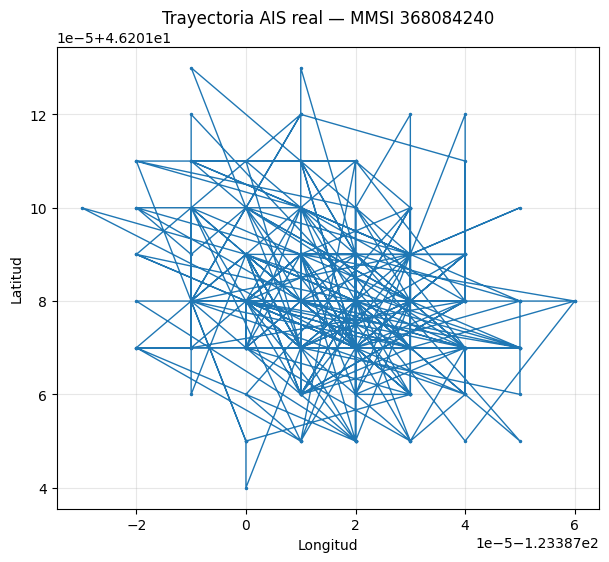

In [ ]:
plt.figure(figsize=(7, 6))
plt.plot(traj["LON"], traj["LAT"], marker=".", linewidth=1, markersize=3)
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.title(f"Trayectoria AIS real — MMSI {candidate_mmsi}")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
lat0 = traj["LAT"].mean()
lon0 = traj["LON"].mean()

# Aproximación local en km
x = (traj["LON"] - lon0) * 111.0 * np.cos(np.deg2rad(lat0))
y = (traj["LAT"] - lat0) * 111.0

t_hours = (
    traj["BaseDateTime"] - traj["BaseDateTime"].min()
).dt.total_seconds() / 3600

k = 10  # km/h, escala temporal
points_st = np.column_stack([x, y, k * t_hours])

points_st = StandardScaler().fit_transform(points_st)

dgms_raw = ripser(points_st, maxdim=1)["dgms"]

### Diagrama de persistencia + barcode

In [ ]:
def plot_barcode(dgms, title="Barcode"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    for dim, ax in enumerate(axes):
        dgm = dgms[dim]
        dgm = dgm[dgm[:, 1] < np.inf]

        if len(dgm) == 0:
            ax.text(0.5, 0.5, "Sin barras finitas", ha="center", va="center")
        else:
            lifetimes = dgm[:, 1] - dgm[:, 0]
            order = np.argsort(lifetimes)
            dgm = dgm[order]

            for i, (birth, death) in enumerate(dgm):
                ax.hlines(i, birth, death, linewidth=2)

        ax.set_title(f"H{dim}")
        ax.set_xlabel("Escala")
        ax.set_ylabel("Feature")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

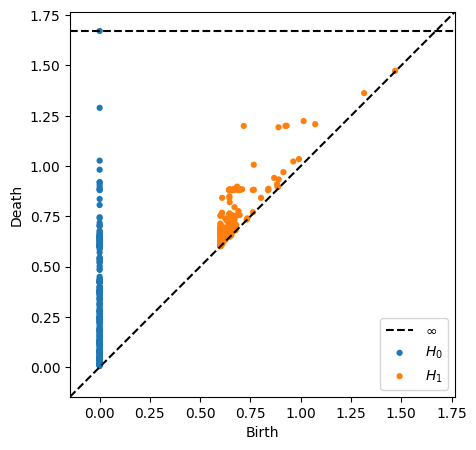

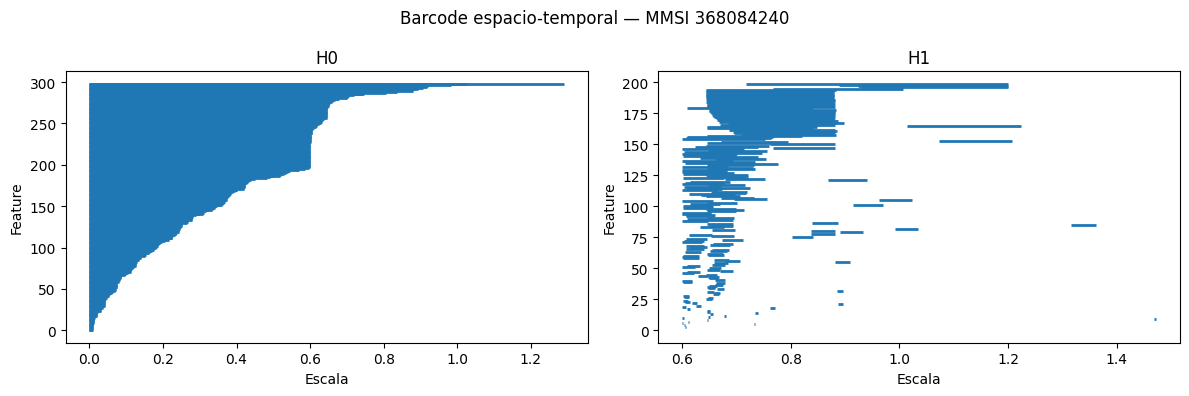

In [ ]:
plt.figure(figsize=(6, 5))
plot_diagrams(dgms_raw, show=True)

plt.show()

plot_barcode(dgms_raw, title=f"Barcode espacio-temporal — MMSI {candidate_mmsi}")

In [ ]:
h1 = dgms_raw[1]
h1 = h1[h1[:, 1] < np.inf]

if len(h1) > 0:
    lifetimes = h1[:, 1] - h1[:, 0]
    print("H1 max:", lifetimes.max())
    print("H1 sum:", lifetimes.sum())
    print("Número de loops:", len(lifetimes))
else:
    print("No hay loops H1 finitos.")

H1 max: 0.48254960775375366
H1 sum: 17.35494726896286
Número de loops: 200


In [ ]:
raw = raw.sort_values(["MMSI", "BaseDateTime"]).copy()

raw["delta_t"] = (
    raw.groupby("MMSI")["BaseDateTime"]
    .diff()
    .dt.total_seconds()
)

GAP_THRESHOLD = 1800  # 30 minutos

raw["new_traj"] = (
    raw["delta_t"].isna() |
    (raw["delta_t"] > GAP_THRESHOLD)
).astype(int)

raw["trajectory_id_raw"] = raw.groupby("MMSI")["new_traj"].cumsum()

raw["trajectory_global_raw"] = (
    raw["MMSI"].astype(str) + "_" +
    raw["trajectory_id_raw"].astype(str)
)

traj_counts = raw["trajectory_global_raw"].value_counts()

print(traj_counts.describe())
print("Trayectorias con más de 50 puntos:", (traj_counts >= 50).sum())

count    32045.000000
mean       178.357372
std        268.338102
min          1.000000
25%          3.000000
50%         33.000000
75%        304.000000
max       1284.000000
Name: count, dtype: float64
Trayectorias con más de 50 puntos: 14602


In [ ]:
def compute_raw_tda_for_traj(traj, max_points=250, k=10):
    traj = traj.sort_values("BaseDateTime").copy()

    if len(traj) > max_points:
        traj = traj.iloc[:max_points].copy()

    lat0 = traj["LAT"].mean()
    lon0 = traj["LON"].mean()

    x = (traj["LON"] - lon0) * 111.0 * np.cos(np.deg2rad(lat0))
    y = (traj["LAT"] - lat0) * 111.0

    t_hours = (
        traj["BaseDateTime"] - traj["BaseDateTime"].min()
    ).dt.total_seconds() / 3600

    points = np.column_stack([x, y, k * t_hours])
    points = StandardScaler().fit_transform(points)

    dgms = ripser(points, maxdim=1)["dgms"]

    h1 = dgms[1]
    h1 = h1[h1[:, 1] < np.inf]

    if len(h1) == 0:
        h1_max = 0
        h1_sum = 0
        n_loops = 0
    else:
        lifetimes = h1[:, 1] - h1[:, 0]
        h1_max = lifetimes.max()
        h1_sum = lifetimes.sum()
        n_loops = len(lifetimes)

    return {
        "h1_max": h1_max,
        "h1_sum": h1_sum,
        "n_loops": n_loops,
        "n_points": len(traj),
        "dgms": dgms,
        "traj": traj
    }

In [ ]:
# Elegimos varias trayectorias suficientemente largas
valid_raw_trajs = traj_counts[traj_counts >= 80].head(20).index

raw_tda_results = []

for traj_id in valid_raw_trajs:
    traj = raw[raw["trajectory_global_raw"] == traj_id]
    res = compute_raw_tda_for_traj(traj)

    raw_tda_results.append({
        "trajectory_global_raw": traj_id,
        "n_points": res["n_points"],
        "h1_max": res["h1_max"],
        "h1_sum": res["h1_sum"],
        "n_loops": res["n_loops"]
    })

raw_tda_df = pd.DataFrame(raw_tda_results)
display(raw_tda_df.sort_values("h1_sum", ascending=False))

,trajectory_global_raw,n_points,h1_max,h1_sum,n_loops
15,367331730_1,250,0.270207,16.845535,162
0,368084240_1,250,0.654937,15.551658,149
2,367531220_1,250,0.501785,12.529009,109
16,367175590_1,250,0.346136,12.075630,119
17,367155110_1,250,0.406782,11.503837,102
19,367544180_1,250,0.306805,10.636163,107
11,367513230_1,250,0.354244,9.784672,155
7,369970411_1,250,0.420642,9.151718,109
1,367001790_1,250,0.420180,8.938326,102
14,366264360_1,250,0.507665,8.042869,129


In [ ]:
low_raw_id = raw_tda_df.sort_values("h1_sum").iloc[0]["trajectory_global_raw"]
high_raw_id = raw_tda_df.sort_values("h1_sum", ascending=False).iloc[0]["trajectory_global_raw"]

print("Baja complejidad:", low_raw_id)
print("Alta complejidad:", high_raw_id)

Baja complejidad: 367384780_1
Alta complejidad: 367331730_1


In [ ]:
def plot_raw_traj_and_tda(traj_id):
    traj = raw[raw["trajectory_global_raw"] == traj_id].copy()
    res = compute_raw_tda_for_traj(traj)

    traj_plot = res["traj"]
    dgms = res["dgms"]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    axes[0].plot(
        traj_plot["LON"],
        traj_plot["LAT"],
        marker=".",
        linewidth=1,
        markersize=3
    )
    axes[0].set_title(
        f"Trayectoria raw\n{traj_id}\n"
        f"H1_sum={res['h1_sum']:.3f}, loops={res['n_loops']}"
    )
    axes[0].set_xlabel("Longitud")
    axes[0].set_ylabel("Latitud")
    axes[0].grid(alpha=0.3)

    dgms_plot = []
    for d in dgms:
        finite = d[d[:, 1] < np.inf] if len(d) > 0 else d
        dgms_plot.append(finite)

    plot_diagrams(dgms_plot, ax=axes[1], show=False)
    axes[1].set_title("Diagrama de persistencia")
    axes[1].set_xlabel("Nacimiento")
    axes[1].set_ylabel("Muerte")

    plt.tight_layout()
    plt.show()

    plot_barcode(dgms, title=f"Barcode espacio-temporal — {traj_id}")

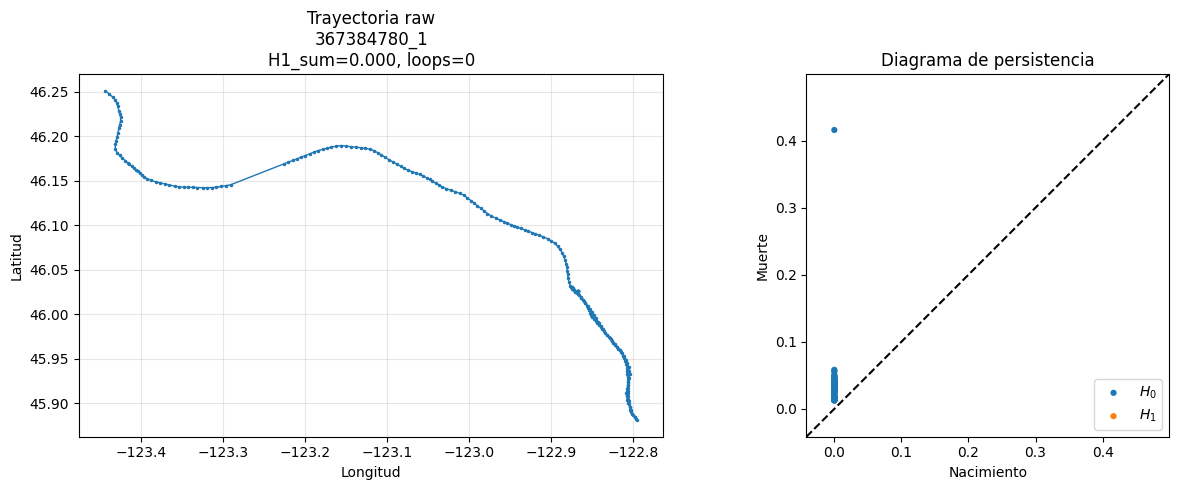

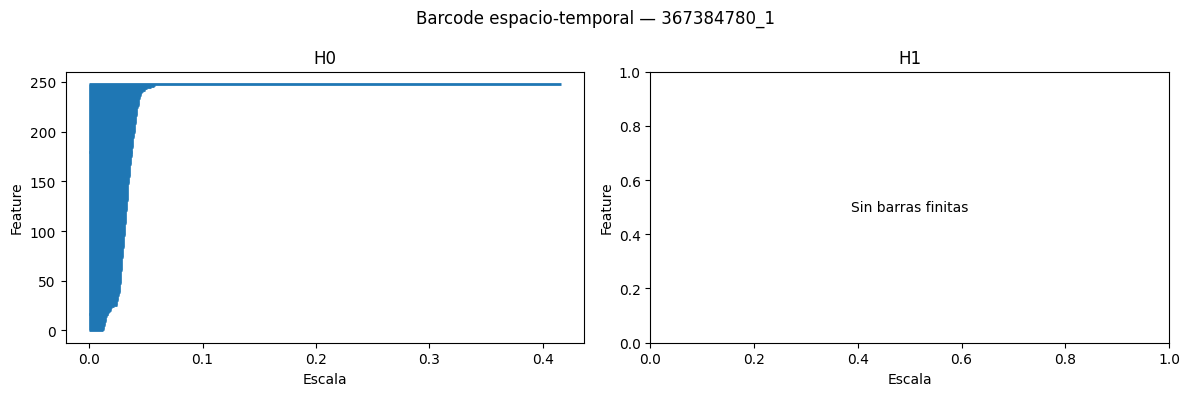

In [ ]:
plot_raw_traj_and_tda(low_raw_id)


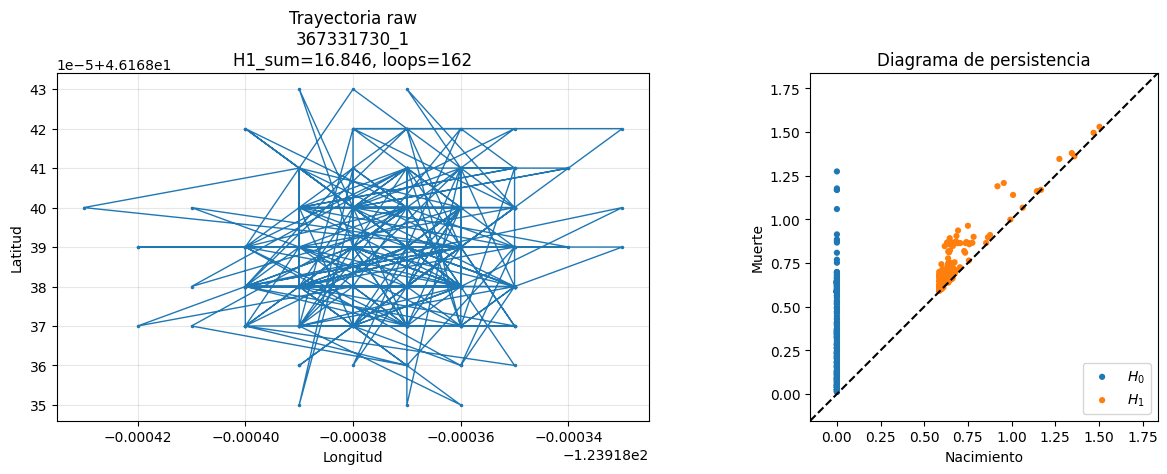

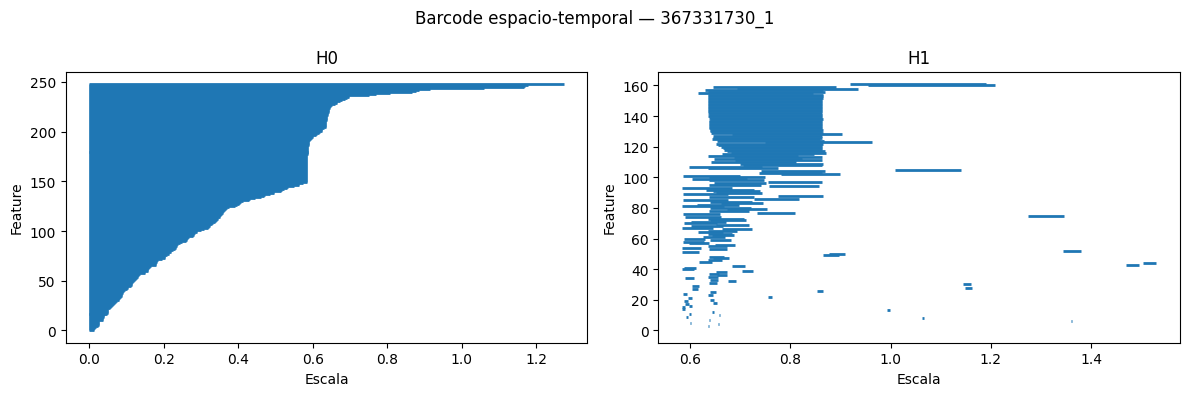

In [ ]:
plot_raw_traj_and_tda(high_raw_id)

## Para muchas trayectorias

In [ ]:
# Elegimos trayectorias raw suficientemente largas
traj_counts = raw["trajectory_global_raw"].value_counts()

valid_raw_trajs = traj_counts[
    (traj_counts >= 80) & (traj_counts <= 500)
].index

print("Trayectorias candidatas:", len(valid_raw_trajs))

raw_tda_results = []

for traj_id in valid_raw_trajs[:300]:  # limitar para que no tarde demasiado
    traj = raw[raw["trajectory_global_raw"] == traj_id]

    try:
        res = compute_raw_tda_for_traj(traj, max_points=250)

        raw_tda_results.append({
            "trajectory_global_raw": traj_id,
            "n_points": res["n_points"],
            "h1_max": res["h1_max"],
            "h1_sum": res["h1_sum"],
            "n_loops": res["n_loops"]
        })

    except Exception as e:
        print("Error en", traj_id, e)

raw_tda_df = pd.DataFrame(raw_tda_results)

display(raw_tda_df.sort_values("h1_sum", ascending=False).head(10))
display(raw_tda_df.sort_values("h1_sum").head(10))

Trayectorias candidatas: 10015


,trajectory_global_raw,n_points,h1_max,h1_sum,n_loops
253,367008020_1,250,0.301690,15.260860,150
87,538071695_1,250,0.390081,14.785335,139
4,219152000_1,250,0.357971,14.578689,160
95,368344540_1,250,0.377125,13.951887,145
206,368283540_1,250,0.391663,13.398267,172
266,367144820_5,250,0.565507,13.227776,118
207,316002063_1,250,0.442208,13.012977,131
158,366892120_1,250,0.442910,12.791103,129
124,366997450_5,250,0.436780,12.068963,107
216,367334040_1,250,0.497800,11.997648,113


,trajectory_global_raw,n_points,h1_max,h1_sum,n_loops
0,538005740_1,250,0.0,0.0,0
1,265050000_1,250,0.0,0.0,0
2,563102700_1,250,0.0,0.0,0
3,316023339_1,250,0.0,0.0,0
5,477914600_1,250,0.0,0.0,0
6,367487570_1,250,0.0,0.0,0
7,367468960_1,250,0.0,0.0,0
8,563064900_1,250,0.0,0.0,0
31,257486000_2,250,0.0,0.0,0
33,366971370_1,250,0.0,0.0,0


In [ ]:
# Normal: trayectoria con H1 = 0 y bastantes puntos
normal_candidates = raw_tda_df[
    (raw_tda_df["h1_sum"] == 0) &
    (raw_tda_df["n_points"] >= 80)
]

normal_raw_id = normal_candidates.iloc[0]["trajectory_global_raw"]

# Anómala candidata: mayor complejidad H1
anomalous_raw_id = raw_tda_df.sort_values(
    "h1_sum", ascending=False
).iloc[0]["trajectory_global_raw"]

print("Trayectoria normal/simple:", normal_raw_id)
print("Trayectoria compleja/anómala candidata:", anomalous_raw_id)

Trayectoria normal/simple: 538005740_1
Trayectoria compleja/anómala candidata: 367008020_1


Comparación

In [ ]:
def compare_raw_trajectories(normal_id, anomalous_id, save_path=None):
    ids = [normal_id, anomalous_id]
    labels = ["Normal / simple", "Compleja / anómala candidata"]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    for row, (traj_id, label) in enumerate(zip(ids, labels)):
        traj = raw[raw["trajectory_global_raw"] == traj_id].copy()
        res = compute_raw_tda_for_traj(traj, max_points=250)

        traj_plot = res["traj"]
        dgms = res["dgms"]

        # Trayectoria lat/lon
        axes[row, 0].plot(
            traj_plot["LON"],
            traj_plot["LAT"],
            marker=".",
            linewidth=1,
            markersize=3
        )
        axes[row, 0].set_title(
            f"{label}\n{traj_id}\n"
            f"H1_sum={res['h1_sum']:.3f}, loops={res['n_loops']}"
        )
        axes[row, 0].set_xlabel("Longitud")
        axes[row, 0].set_ylabel("Latitud")
        axes[row, 0].grid(alpha=0.3)

        # Diagrama de persistencia
        dgms_plot = []
        for d in dgms:
            finite = d[d[:, 1] < np.inf] if len(d) > 0 else d
            dgms_plot.append(finite)

        plot_diagrams(dgms_plot, ax=axes[row, 1], show=False)
        axes[row, 1].set_title("Diagrama de persistencia")
        axes[row, 1].set_xlabel("Nacimiento")
        axes[row, 1].set_ylabel("Muerte")

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()

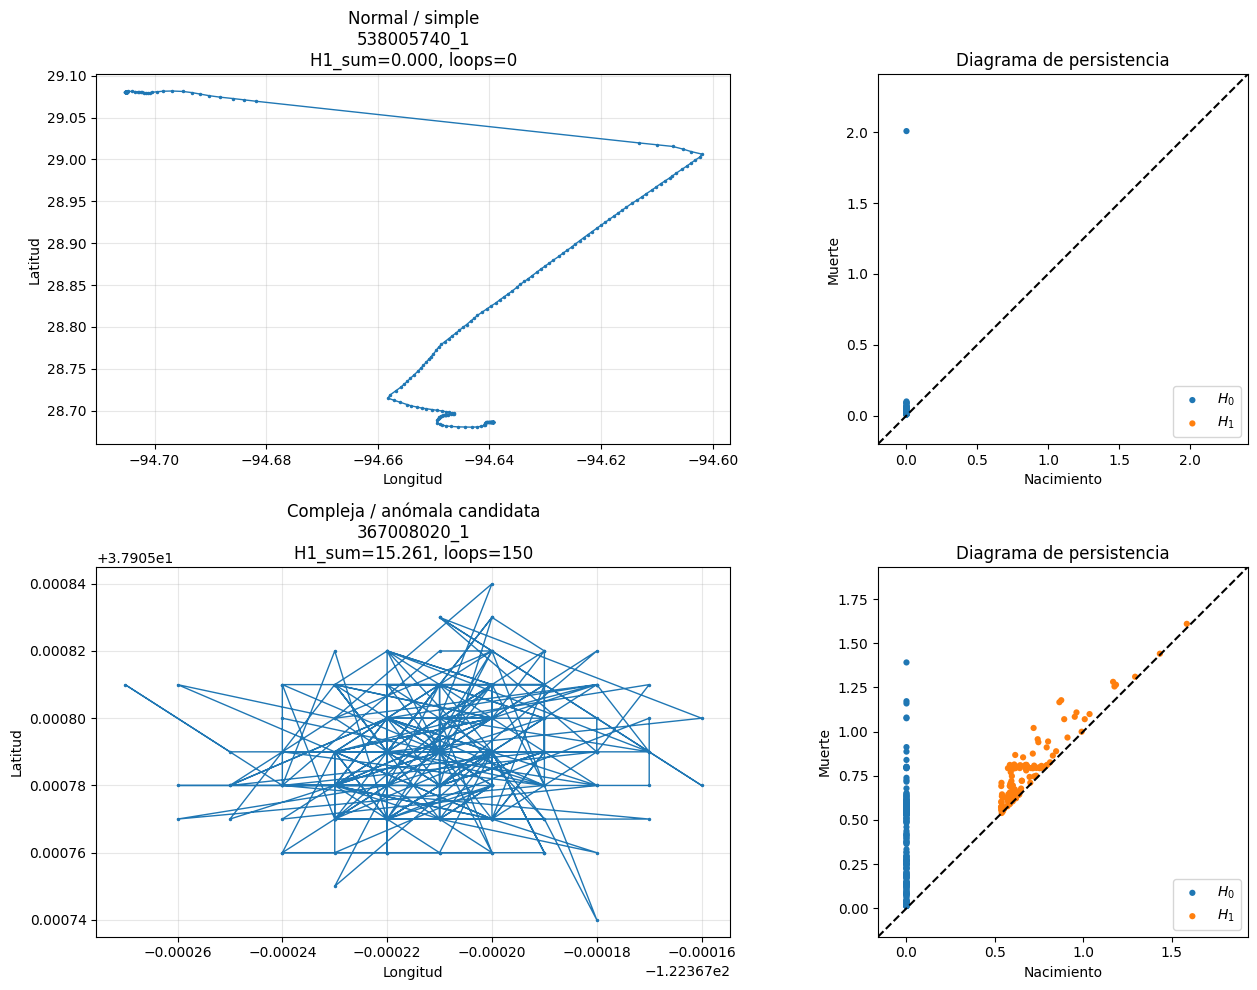

In [ ]:

FIG_DIR = "/content/drive/MyDrive/TFG/results/tda/figures"
os.makedirs(FIG_DIR, exist_ok=True)

compare_raw_trajectories(
    normal_raw_id,
    anomalous_raw_id,
    save_path=os.path.join(FIG_DIR, "raw_normal_vs_anomalous_tda.png")
)

La trayectoria 538005740_1 topológicamente es considerada como una trayectoria normal/simple, sin embargo, al ojo humano podemos observar entre el cuadrante de longitud -94,66 a -94,64 un giro un tanto "anómalo". Esto muestra la limitación conocida del TDA, por lo que fortalece el uso de un enfoque híbrido.

In [ ]:
def plot_barcode_paper_style(dgms, title="Barcode", save_path=None):
    """
    Barcode estilo paper: barras horizontales separadas por dimensión H0, H1, H2...
    """
    fig, ax = plt.subplots(figsize=(10, 5))

    y_offset = 0
    y_ticks = []
    y_labels = []

    colors = {
        0: "tab:red",
        1: "tab:green",
        2: "tab:purple"
    }

    for dim, dgm in enumerate(dgms):
        if len(dgm) == 0:
            continue

        dgm = dgm[dgm[:, 1] < np.inf]

        if len(dgm) == 0:
            continue

        lifetimes = dgm[:, 1] - dgm[:, 0]
        order = np.argsort(lifetimes)[::-1]
        dgm = dgm[order]

        for i, (birth, death) in enumerate(dgm):
            ax.hlines(
                y=y_offset + i,
                xmin=birth,
                xmax=death,
                color=colors.get(dim, "black"),
                linewidth=2
            )

        y_ticks.append(y_offset + len(dgm) / 2)
        y_labels.append(f"$H_{dim}$")

        y_offset += len(dgm) + 5

    ax.set_xlabel("Escala $\\varepsilon$")
    ax.set_ylabel("Dimensión homológica")
    ax.set_yticks(y_ticks)
    ax.set_yticklabels(y_labels)
    ax.set_title(title)
    ax.grid(axis="x", alpha=0.3)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()

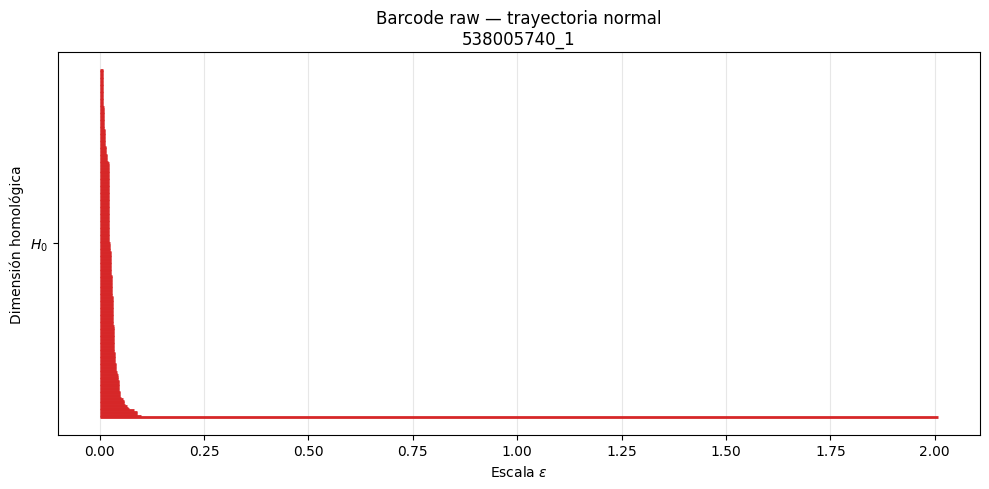

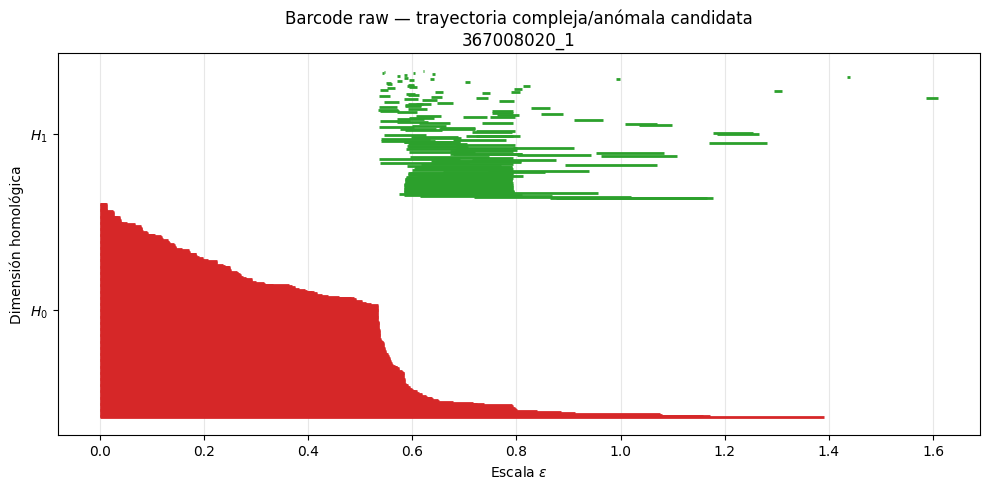

In [ ]:
normal_res = compute_raw_tda_for_traj(
    raw[raw["trajectory_global_raw"] == normal_raw_id],
    max_points=250
)

anom_res = compute_raw_tda_for_traj(
    raw[raw["trajectory_global_raw"] == anomalous_raw_id],
    max_points=250
)

plot_barcode_paper_style(
    normal_res["dgms"],
    title=f"Barcode raw — trayectoria normal\n{normal_raw_id}",
    save_path=os.path.join(FIG_DIR, f"barcode_raw_normal_{normal_raw_id}.png")
)

plot_barcode_paper_style(
    anom_res["dgms"],
    title=f"Barcode raw — trayectoria compleja/anómala candidata\n{anomalous_raw_id}",
    save_path=os.path.join(FIG_DIR, f"barcode_raw_anomalous_{anomalous_raw_id}.png")
)

## Visualización barcodes

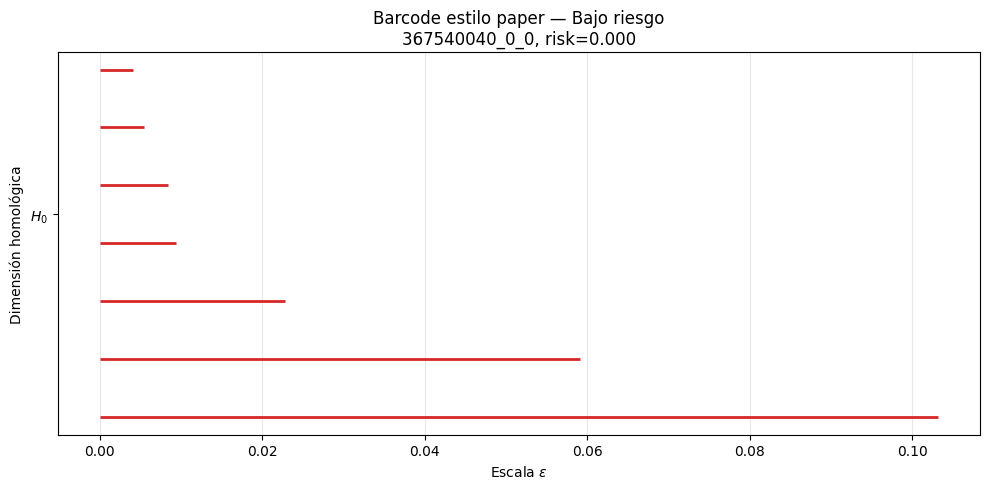

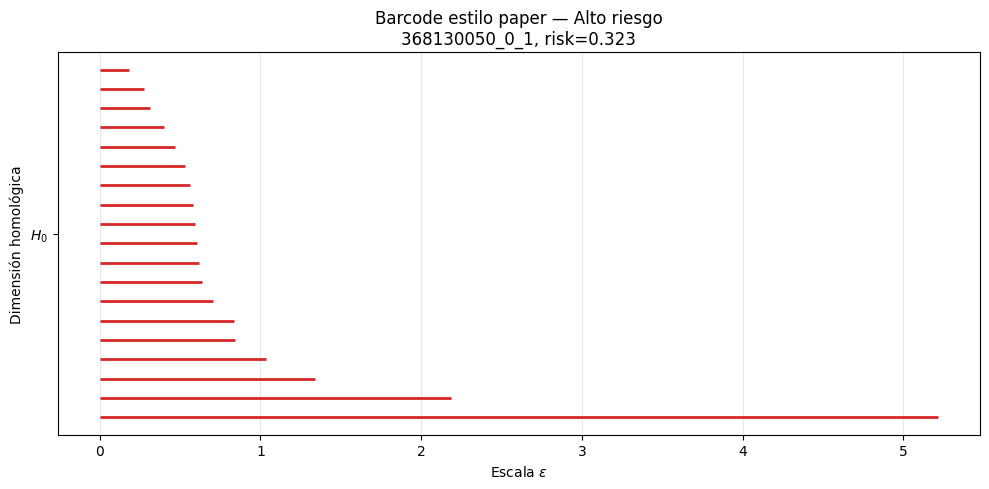

In [ ]:
import os

FIG_DIR = "/content/drive/MyDrive/TFG/results/tda/figures"
os.makedirs(FIG_DIR, exist_ok=True)

for key, label in [("low_risk", "Bajo riesgo"), ("high_risk", "Alto riesgo")]:
    dgms, risk_val, subtraj_id = sample_diagrams[key]

    plot_barcode_paper_style(
        dgms,
        title=f"Barcode estilo paper — {label}\n{subtraj_id}, risk={risk_val:.3f}",
        save_path=os.path.join(FIG_DIR, f"barcode_paper_{key}.png")
    )

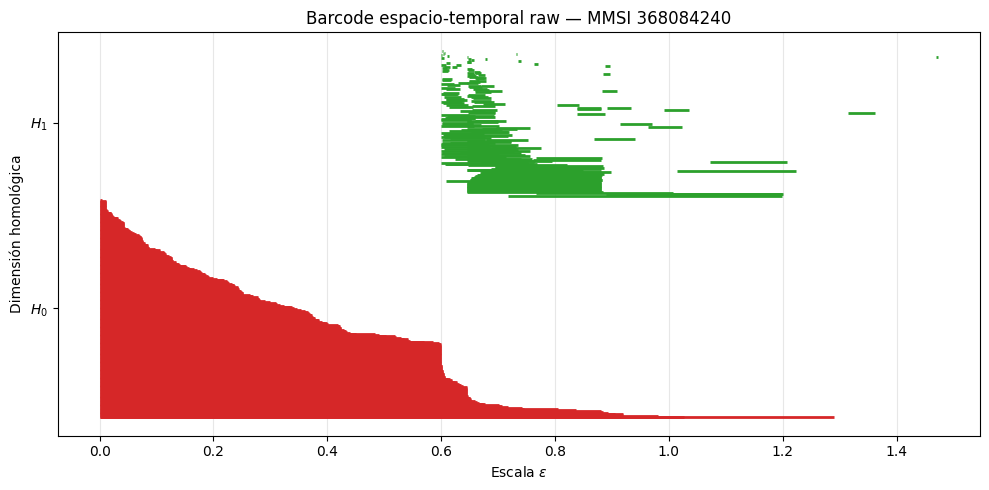

In [ ]:
plot_barcode_paper_style(
    dgms_raw,
    title=f"Barcode espacio-temporal raw — MMSI {candidate_mmsi}",
    save_path=os.path.join(FIG_DIR, f"barcode_raw_mmsi_{candidate_mmsi}.png")
)

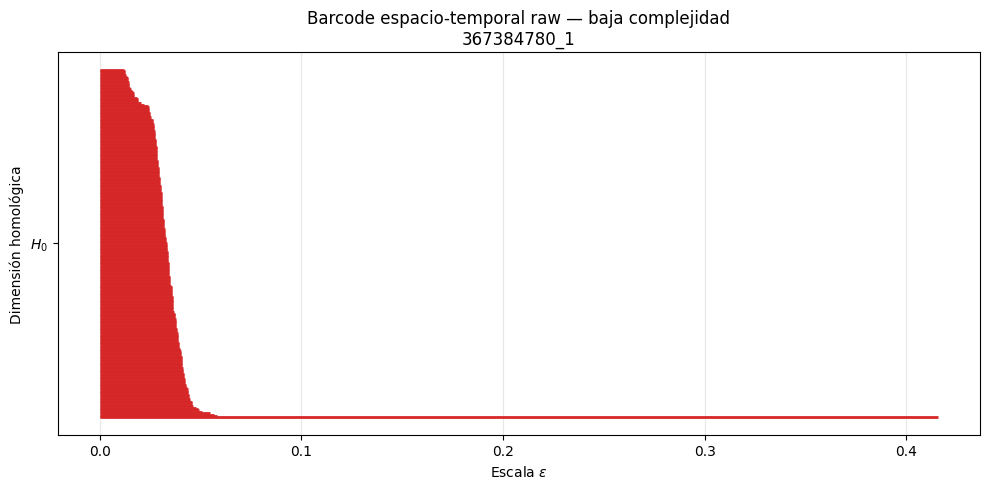

In [ ]:

low_res = compute_raw_tda_for_traj(
    raw[raw["trajectory_global_raw"] == low_raw_id]
)

plot_barcode_paper_style(
    low_res["dgms"],
    title=f"Barcode espacio-temporal raw — baja complejidad\n{low_raw_id}",
    save_path=os.path.join(FIG_DIR, f"barcode_raw_low_{low_raw_id}.png")
)

## Anomalías locales vs globales

In [ ]:
# detectar anomalías locales sin complejidad topológica

local_anomalies = tda_df.merge(
    df_tda.groupby("subtraj_global")[[
        "delta_course_max", "turning_rate_max"
    ]].max(),
    left_on="subtraj_global",
    right_index=True
)

local_anomalies = local_anomalies[
    (local_anomalies["tda_h1_sum"] == 0) &
    (
        (local_anomalies["delta_course_max"] > 90) |
        (local_anomalies["turning_rate_max"] > 30)
    )
]

print("Anomalías locales detectadas:", len(local_anomalies))
local_anomalies.head()

Anomalías locales detectadas: 441


,subtraj_global,tda_h0_sum,tda_h1_max,tda_h1_sum,tda_n_loops,risk_proxy_mean,risk_label_mode,n_points,delta_course_max,turning_rate_max
2,210271000_9_0,11.432408,0.0,0.0,0,0.206871,0,20,166.400000,5.286667
4,210411000_0_0,9.564811,0.0,0.0,0,0.150316,1,20,179.500000,1.860000
7,218292000_0_0,12.629909,0.0,0.0,0,0.169869,1,16,426.383918,2.382033
11,227489210_0_0,5.348700,0.0,0.0,0,0.168552,2,9,131.500000,0.626190
16,244283000_0_0,6.404418,0.0,0.0,0,0.191347,0,11,176.600000,1.924194


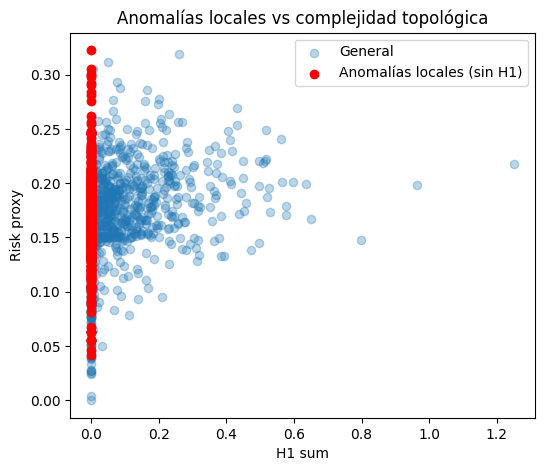

In [ ]:
plt.figure(figsize=(6,5))

plt.scatter(
    tda_df["tda_h1_sum"],
    tda_df["risk_proxy_mean"],
    alpha=0.3,
    label="General"
)

plt.scatter(
    local_anomalies["tda_h1_sum"],
    local_anomalies["risk_proxy_mean"],
    color="red",
    label="Anomalías locales (sin H1)"
)

plt.xlabel("H1 sum")
plt.ylabel("Risk proxy")
plt.legend()
plt.title("Anomalías locales vs complejidad topológica")

plt.show()

## Comparación con resultados ML

In [ ]:
analysis_df = tda_df.merge(
    df_tda.groupby("subtraj_global")[[
        "hybrid_score", "rule_score_norm"
    ]].mean(),
    left_on="subtraj_global",
    right_index=True
)

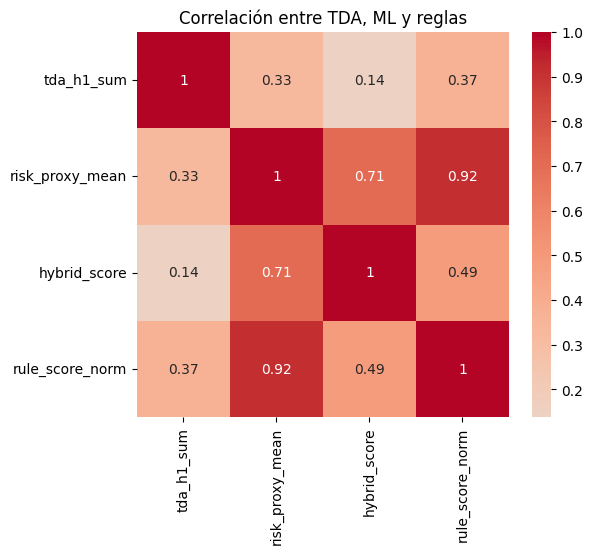

In [ ]:
cols = [
    "tda_h1_sum",
    "risk_proxy_mean",
    "hybrid_score",
    "rule_score_norm"
]

corr = analysis_df[cols].corr(method="spearman")

import seaborn as sns
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlación entre TDA, ML y reglas")
plt.show()

El mapa de correlación muestra que las métricas topológicas presentan una correlación moderada con el `risk_proxy`, pero una correlación baja con los modelos de aprendizaje automático (`hybrid_score`). Esto indica que el análisis topológico no replica la información capturada por los modelos ML, sino que aporta una dimensión complementaria basada en la estructura geométrica de las trayectorias.

En particular, mientras que el `risk_proxy` está fuertemente influenciado por las reglas expertas y el modelo híbrido, la complejidad topológica (H₁) captura patrones distintos, lo que refuerza la utilidad del enfoque combinado.

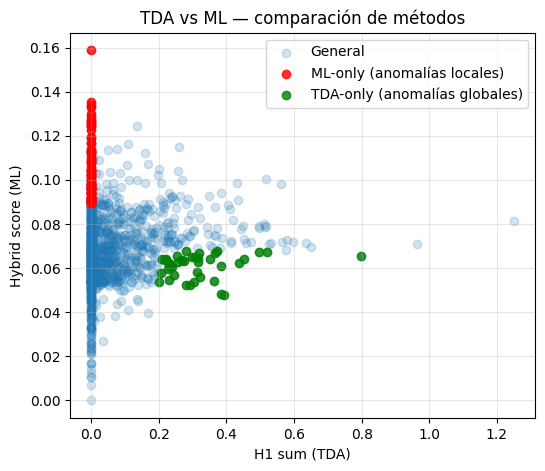

In [ ]:
plt.figure(figsize=(6,5))

# General (gris suave)
plt.scatter(
    analysis_df["tda_h1_sum"],
    analysis_df["hybrid_score"],
    alpha=0.2,
    label="General"
)

# ML-only (rojo)
plt.scatter(
    ml_only["tda_h1_sum"],
    ml_only["hybrid_score"],
    color="red",
    alpha=0.8,
    label="ML-only (anomalías locales)"
)

# TDA-only (verde)
plt.scatter(
    tda_only["tda_h1_sum"],
    tda_only["hybrid_score"],
    color="green",
    alpha=0.8,
    label="TDA-only (anomalías globales)"
)

plt.xlabel("H1 sum (TDA)")
plt.ylabel("Hybrid score (ML)")
plt.title("TDA vs ML — comparación de métodos")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

El diagrama de dispersión permite identificar dos tipos diferenciados de anomalías:

- **ML-only (rojo):** trayectorias detectadas como anómalas por modelos estadísticos o reglas, pero sin complejidad topológica. Estas corresponden a anomalías locales, como giros bruscos o cambios puntuales de comportamiento.

- **TDA-only (verde):** trayectorias con alta complejidad topológica, pero no necesariamente detectadas por los modelos ML. Estas representan anomalías globales, caracterizadas por patrones estructurados, bucles o comportamientos repetitivos.

Este resultado evidencia que los distintos enfoques capturan dimensiones complementarias del comportamiento marítimo, lo que justifica el uso de un sistema híbrido.

Desacuerdos

In [ ]:
# TDA alto pero ML bajo → anomalías geométricas
tda_only = analysis_df[
    (analysis_df["tda_h1_sum"] > analysis_df["tda_h1_sum"].quantile(0.9)) &
    (analysis_df["hybrid_score"] < analysis_df["hybrid_score"].quantile(0.5))
]

# ML alto pero TDA bajo → anomalías locales
ml_only = analysis_df[
    (analysis_df["hybrid_score"] > analysis_df["hybrid_score"].quantile(0.9)) &
    (analysis_df["tda_h1_sum"] == 0)
]

print("TDA-only:", len(tda_only))
print("ML-only:", len(ml_only))

tda_only.head()
ml_only.head()

TDA-only: 40
ML-only: 83


,subtraj_global,tda_h0_sum,tda_h1_max,tda_h1_sum,tda_n_loops,risk_proxy_mean,risk_label_mode,n_points,hybrid_score,rule_score_norm
35,257682000_0_0,12.579466,0.0,0.0,0,0.256361,3,20,0.101991,0.378049
40,303200000_5_0,16.893852,0.0,0.0,0,0.299336,3,8,0.107442,0.533537
47,305350000_0_0,10.924808,0.0,0.0,0,0.185738,2,12,0.089785,0.228659
64,316001717_0_0,1.099321,0.0,0.0,0,0.205643,0,8,0.132980,0.182927
73,316003677_0_1,4.850524,0.0,0.0,0,0.193895,0,8,0.097298,0.256098


## Guardado

In [ ]:
import os
import json

BASE_OUTPUT = "/content/drive/MyDrive/TFG/results/tda"

# Crear estructura de carpetas
CSV_DIR = os.path.join(BASE_OUTPUT, "data")
FIG_DIR = os.path.join(BASE_OUTPUT, "figures")
META_DIR = os.path.join(BASE_OUTPUT, "meta")

os.makedirs(CSV_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(META_DIR, exist_ok=True)


# 1. Guardar dataframe TDA

csv_path = os.path.join(CSV_DIR, "tda_results.csv")
tda_df.to_csv(csv_path, index=False)


# 2. Guardar estadísticas resumen

summary = {
    "n_subtraj": int(len(tda_df)),
    "h1_sum_mean": float(tda_df["tda_h1_sum"].mean()),
    "h1_sum_std": float(tda_df["tda_h1_sum"].std()),
    "risk_mean": float(tda_df["risk_proxy_mean"].mean()),
    "correlation_spearman_h1": float(
        tda_df[["tda_h1_sum", "risk_proxy_mean"]]
        .corr(method="spearman")
        .iloc[0, 1]
    )
}

summary_path = os.path.join(META_DIR, "summary.json")
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=4)


# 3. Guardar figuras


# Scatter TDA vs Risk
plt.figure(figsize=(7,5))
plt.scatter(
    tda_df["tda_h1_sum"],
    tda_df["risk_proxy_mean"],
    alpha=0.5
)
plt.xlabel("H1 sum")
plt.ylabel("Risk proxy")
plt.title("TDA vs Risk Proxy")
plt.grid()

scatter_path = os.path.join(FIG_DIR, "tda_vs_risk.png")
plt.savefig(scatter_path, dpi=150, bbox_inches="tight")
plt.close()

# Boxplot por risk_label
plt.figure(figsize=(7,5))
tda_df.boxplot(column="tda_h1_sum", by="risk_label_mode")

plt.title("H1 por nivel de riesgo")
plt.suptitle("")
plt.xlabel("Risk label")
plt.ylabel("H1 sum")

boxplot_path = os.path.join(FIG_DIR, "tda_boxplot.png")
plt.savefig(boxplot_path, dpi=150, bbox_inches="tight")
plt.close()


# 4. Guardar diagramas

if "sample_diagrams" in globals():
    for key, (dgms, risk_val, subtraj_id) in sample_diagrams.items():

        plt.figure(figsize=(6,5))

        dgms_plot = []
        for d in dgms:
            finite = d[d[:, 1] < np.inf] if len(d) > 0 else d
            dgms_plot.append(finite)

        plot_diagrams(dgms_plot, show=False)

        plt.title(f"{key} — {subtraj_id}\nrisk={risk_val:.3f}")

        diag_path = os.path.join(FIG_DIR, f"diagram_{key}.png")
        plt.savefig(diag_path, dpi=150, bbox_inches="tight")
        plt.close()

print("=== GUARDADO COMPLETO ===")
print(f"CSV: {csv_path}")
print(f"Figuras: {FIG_DIR}")
print(f"Resumen: {summary_path}")
print(f"Shape: {tda_df.shape}")

=== GUARDADO COMPLETO ===
CSV: /content/drive/MyDrive/TFG/results/tda/data/tda_results.csv
Figuras: /content/drive/MyDrive/TFG/results/tda/figures
Resumen: /content/drive/MyDrive/TFG/results/tda/meta/summary.json
Shape: (1429, 8)


<Figure size 700x500 with 0 Axes>

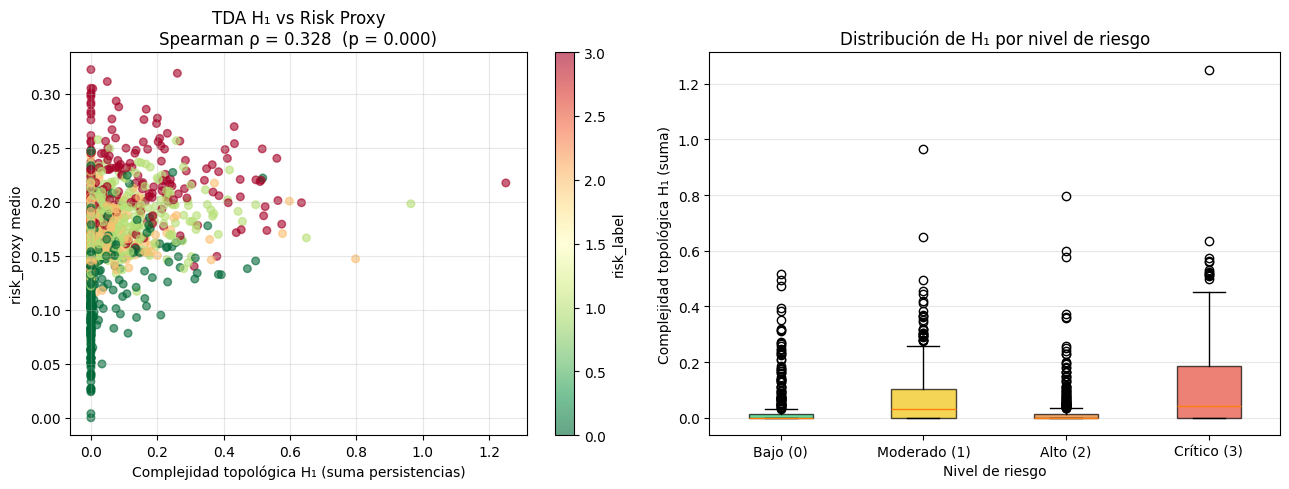

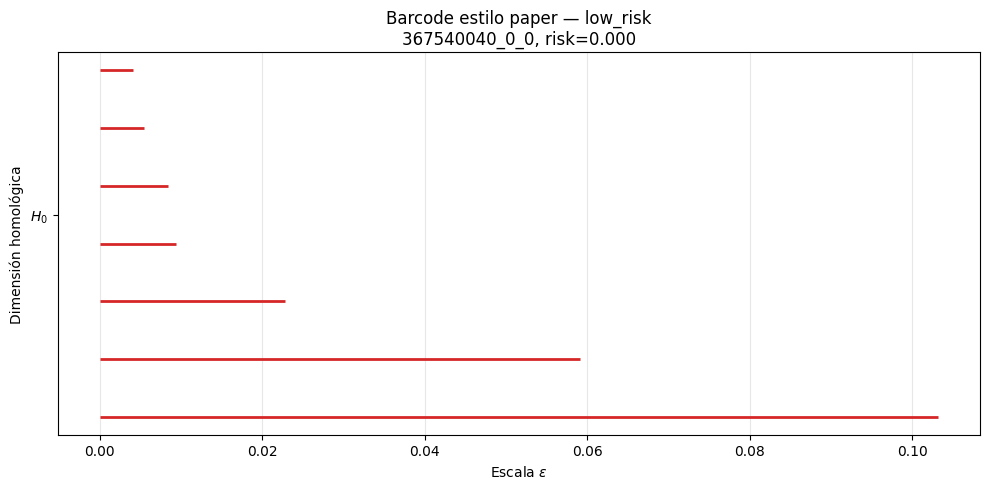

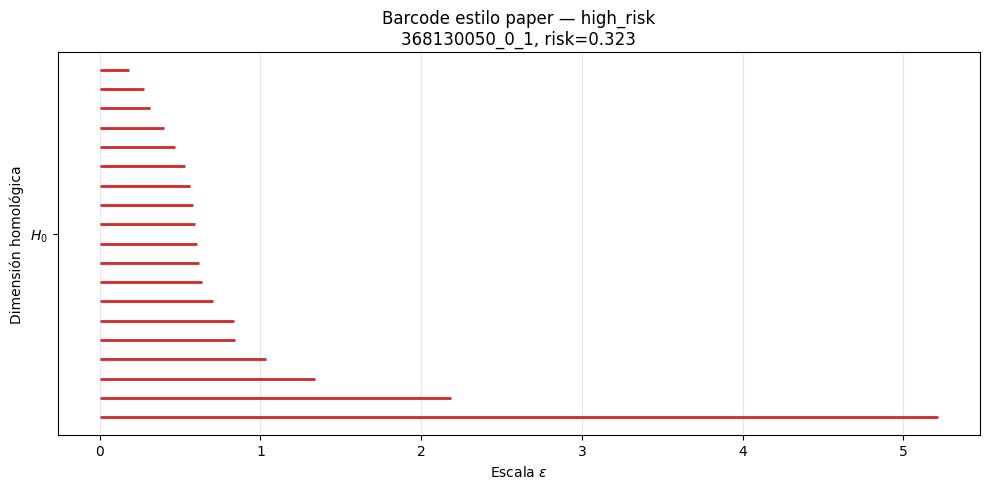

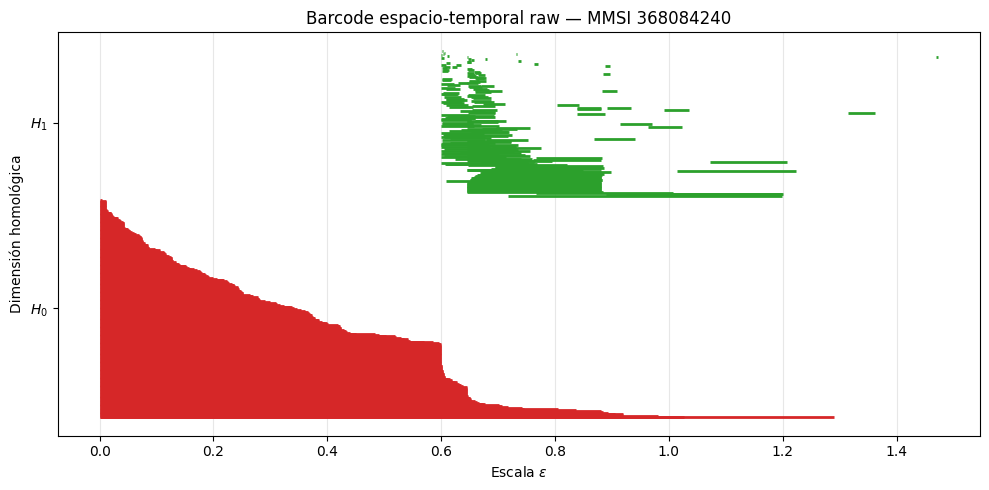

=== GUARDADO COMPLETO ===
Resultados TDA: /content/drive/MyDrive/TFG/results/tda/data/tda_results.csv
Resumen: /content/drive/MyDrive/TFG/results/tda/meta/tda_summary.json
Figuras: /content/drive/MyDrive/TFG/results/tda/figures
Shape TDA: (1429, 8)


In [ ]:
import os
import json

BASE_OUTPUT = "/content/drive/MyDrive/TFG/results/tda"
DATA_DIR = os.path.join(BASE_OUTPUT, "data")
FIG_DIR = os.path.join(BASE_OUTPUT, "figures")
META_DIR = os.path.join(BASE_OUTPUT, "meta")

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(META_DIR, exist_ok=True)

# Guardar resultados principales
tda_path = os.path.join(DATA_DIR, "tda_results.csv")
tda_df.to_csv(tda_path, index=False)

# Guardar resumen
summary = {
    "n_subtrajectories": int(len(tda_df)),
    "tda_h1_sum_mean": float(tda_df["tda_h1_sum"].mean()),
    "tda_h1_sum_std": float(tda_df["tda_h1_sum"].std()),
    "risk_proxy_mean": float(tda_df["risk_proxy_mean"].mean()),
    "spearman_h1_risk": float(
        tda_df[["tda_h1_sum", "risk_proxy_mean"]]
        .corr(method="spearman")
        .iloc[0, 1]
    )
}

summary_path = os.path.join(META_DIR, "tda_summary.json")
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=4)

# Guardar gráfico TDA vs riesgo + boxplot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
sc = ax.scatter(
    tda_df["tda_h1_sum"],
    tda_df["risk_proxy_mean"],
    c=tda_df["risk_label_mode"],
    cmap="RdYlGn_r",
    alpha=0.6,
    s=30
)
plt.colorbar(sc, ax=ax, label="risk_label")
r, p = spearmanr(tda_df["tda_h1_sum"], tda_df["risk_proxy_mean"])
ax.set_xlabel("Complejidad topológica H₁ (suma persistencias)")
ax.set_ylabel("risk_proxy medio")
ax.set_title(f"TDA H₁ vs Risk Proxy\nSpearman ρ = {r:.3f}  (p = {p:.3f})")
ax.grid(alpha=0.3)

ax = axes[1]
groups = [
    tda_df[tda_df["risk_label_mode"] == i]["tda_h1_sum"].values
    for i in sorted(tda_df["risk_label_mode"].unique())
]
labels = ["Bajo (0)", "Moderado (1)", "Alto (2)", "Crítico (3)"][:len(groups)]
bp = ax.boxplot(groups, tick_labels=labels, patch_artist=True)
colors = ["#2ecc71", "#f1c40f", "#e67e22", "#e74c3c"]

for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel("Complejidad topológica H₁ (suma)")
ax.set_xlabel("Nivel de riesgo")
ax.set_title("Distribución de H₁ por nivel de riesgo")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
tda_vs_risk_path = os.path.join(FIG_DIR, "tda_vs_risk_and_boxplot.png")
plt.savefig(tda_vs_risk_path, dpi=200, bbox_inches="tight")
plt.show()

# Guardar diagramas y barcodes high/low risk
if "sample_diagrams" in globals():
    for key, (dgms, risk_val, subtraj_id) in sample_diagrams.items():

        dgms_plot = []
        for d in dgms:
            finite = d[d[:, 1] < np.inf] if len(d) > 0 else d
            dgms_plot.append(finite)

        plt.figure(figsize=(6, 5))
        plot_diagrams(dgms_plot, show=False)
        plt.title(f"{key} — {subtraj_id}\nrisk={risk_val:.3f}")
        diagram_path = os.path.join(FIG_DIR, f"diagram_{key}.png")
        plt.savefig(diagram_path, dpi=200, bbox_inches="tight")
        plt.close()

        plot_barcode_paper_style(
            dgms,
            title=f"Barcode estilo paper — {key}\n{subtraj_id}, risk={risk_val:.3f}",
            save_path=os.path.join(FIG_DIR, f"barcode_paper_{key}.png")
        )

# Guardar raw NOAA si existe
if "dgms_raw" in globals() and "candidate_mmsi" in globals():
    plt.figure(figsize=(6, 5))
    plot_diagrams(dgms_raw, show=False)
    plt.title(f"Diagrama raw NOAA — MMSI {candidate_mmsi}")
    raw_diag_path = os.path.join(FIG_DIR, f"diagram_raw_mmsi_{candidate_mmsi}.png")
    plt.savefig(raw_diag_path, dpi=200, bbox_inches="tight")
    plt.close()

    plot_barcode_paper_style(
        dgms_raw,
        title=f"Barcode espacio-temporal raw — MMSI {candidate_mmsi}",
        save_path=os.path.join(FIG_DIR, f"barcode_raw_mmsi_{candidate_mmsi}.png")
    )

print("=== GUARDADO COMPLETO ===")
print(f"Resultados TDA: {tda_path}")
print(f"Resumen: {summary_path}")
print(f"Figuras: {FIG_DIR}")
print(f"Shape TDA: {tda_df.shape}")

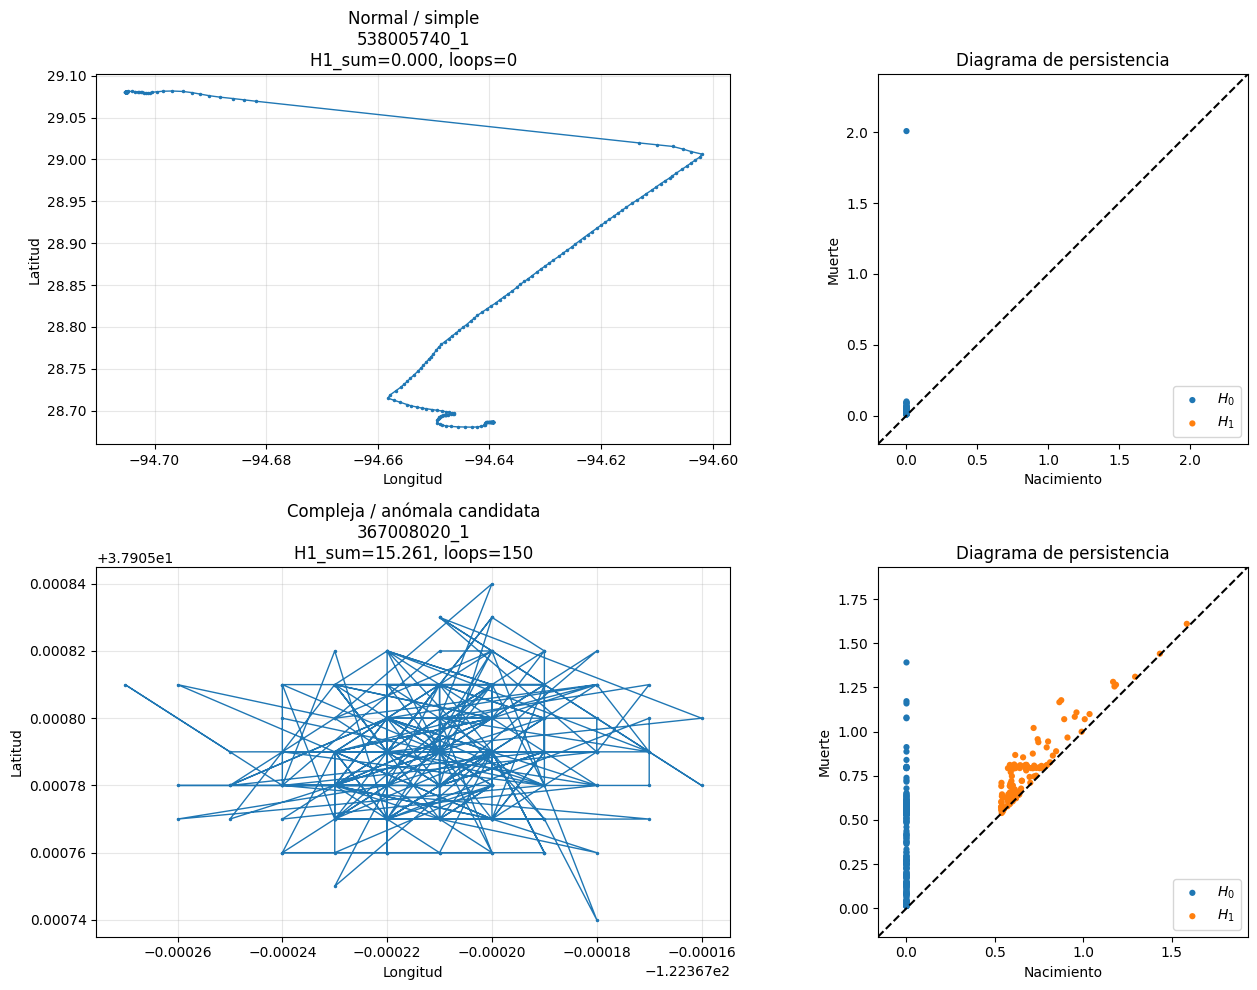

Comparación raw guardada: /content/drive/MyDrive/TFG/results/tda/figures/raw_normal_vs_anomalous_tda.png


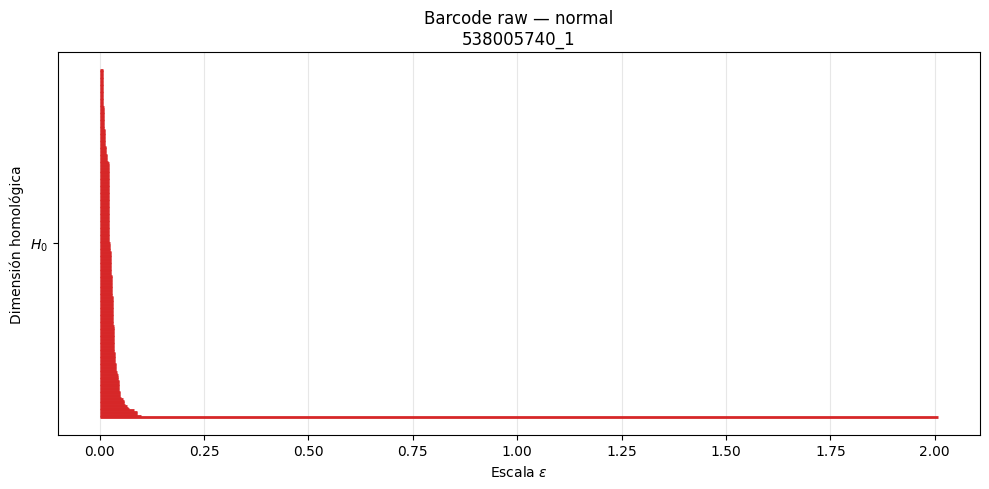

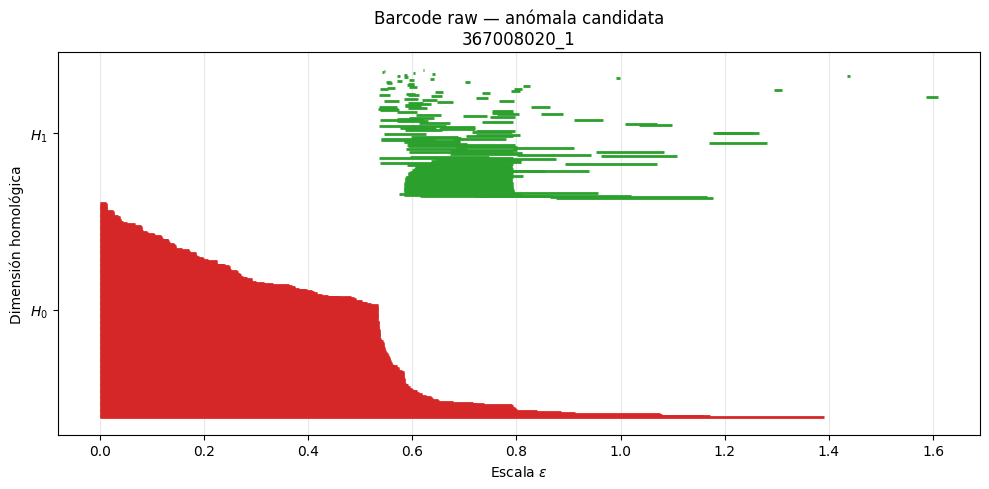

Barcodes raw guardados


In [ ]:
# =========================
# 5. Guardar comparación raw normal vs anómala
# =========================

if "normal_raw_id" in globals() and "anomalous_raw_id" in globals():

    comparison_path = os.path.join(FIG_DIR, "raw_normal_vs_anomalous_tda.png")

    compare_raw_trajectories(
        normal_raw_id,
        anomalous_raw_id,
        save_path=comparison_path
    )

    print(f"Comparación raw guardada: {comparison_path}")

# =========================
# 6. Guardar barcodes raw (normal vs anómalo)
# =========================

if "normal_raw_id" in globals():
    normal_res = compute_raw_tda_for_traj(
        raw[raw["trajectory_global_raw"] == normal_raw_id],
        max_points=250
    )

    plot_barcode_paper_style(
        normal_res["dgms"],
        title=f"Barcode raw — normal\n{normal_raw_id}",
        save_path=os.path.join(FIG_DIR, f"barcode_raw_normal_{normal_raw_id}.png")
    )

if "anomalous_raw_id" in globals():
    anom_res = compute_raw_tda_for_traj(
        raw[raw["trajectory_global_raw"] == anomalous_raw_id],
        max_points=250
    )

    plot_barcode_paper_style(
        anom_res["dgms"],
        title=f"Barcode raw — anómala candidata\n{anomalous_raw_id}",
        save_path=os.path.join(FIG_DIR, f"barcode_raw_anomalous_{anomalous_raw_id}.png")
    )

print("Barcodes raw guardados")